# VaR Backtesting — Code Companion

This notebook computes all statistics documented in the accompanying reference files:

- **Methodology:** `documentation/VaR_backtesting_methodology.md` — test construction, formulas, and interpretation
- **Results:** `documentation/VaR_backtest_result.md` — all numerical outputs, findings, and MRM actions

**Sections**
1. Setup
2. Backtest Computation
3. Breach Visualisation & P&L Attribution
4. Kupiec POF Test
5. Christoffersen Independence & Conditional Coverage Test
6. Window-Size Sensitivity
7. EWMA Volatility-Weighted VaR
8. ES / CVaR Backtest
9. Basel Traffic Light

## 1. Setup

In [16]:
from utils import setup_repo_root

repo_root = setup_repo_root()
print("Working directory:", repo_root)

Working directory: /home/martin/python/risk-assessment


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.ticker import FuncFormatter
from scipy.stats import chi2, weibull_min

from backtest import run_rolling_backtest, run_rolling_backtest_ewma
from data_loader import clean_prices, load_positions, load_prices
from risk_metrics import (
    basel_traffic_light,
    christoffersen_independence_test,
    christoffersen_pelletier_test,
    es_coverage_test,
)

plt.rcParams.update({"figure.dpi": 120, "figure.figsize": (12, 4)})
pd.set_option("display.float_format", "{:.6f}".format)

In [18]:
positions = load_positions()
prices_raw = load_prices()
prices_clean = clean_prices(prices_raw)

prices_wide = (
    prices_clean
    .pivot(index="date", columns="instrument_id", values="price")
    .sort_index()
)
returns = prices_wide.pct_change().dropna(how="all")

weights = positions.set_index("instrument_id")["weight"]
common = returns.columns.intersection(weights.index)
port_returns = returns[common].dot(weights[common])

print(f"Portfolio return series: {len(port_returns)} days")
print(f"  {port_returns.index.min().date()} → {port_returns.index.max().date()}")

Portfolio return series: 252 days
  2025-04-01 → 2026-03-18


## 2. Backtest Computation
*Methodology: `VaR_backtesting_methodology.md` section 2 · Results: `VaR_backtest_result.md` section 1*

In [ ]:
WINDOW = 60
CONFIDENCE = 0.99

result = run_rolling_backtest(port_returns, window=WINDOW, confidence=CONFIDENCE)

var_series     = result["var_series"]
actual_returns = result["actual_returns"]
breach_dates   = result["breach_dates"]

print(f"Backtest period:    {actual_returns.index.min().date()} → "
      f"{actual_returns.index.max().date()}")
print(f"Observations:       {result['n_observations']}")
print(f"Expected breaches:  {result['expected_breaches']:.1f}  "
      f"({1 - CONFIDENCE:.0%} x {result['n_observations']} days)")
print(f"Observed breaches:  {result['n_breaches']}")
print(f"Observed rate:      {result['n_breaches'] / result['n_observations']:.2%}")

Backtest period:    2025-06-24 → 2026-03-18
Observations:       192
Expected breaches:  1.9  (1% × 192 days)
Observed breaches:  7
Observed rate:      3.65%


## 3. Breach Visualisation & P&L Attribution
*Results: `VaR_backtest_result.md` section 1, section 4*

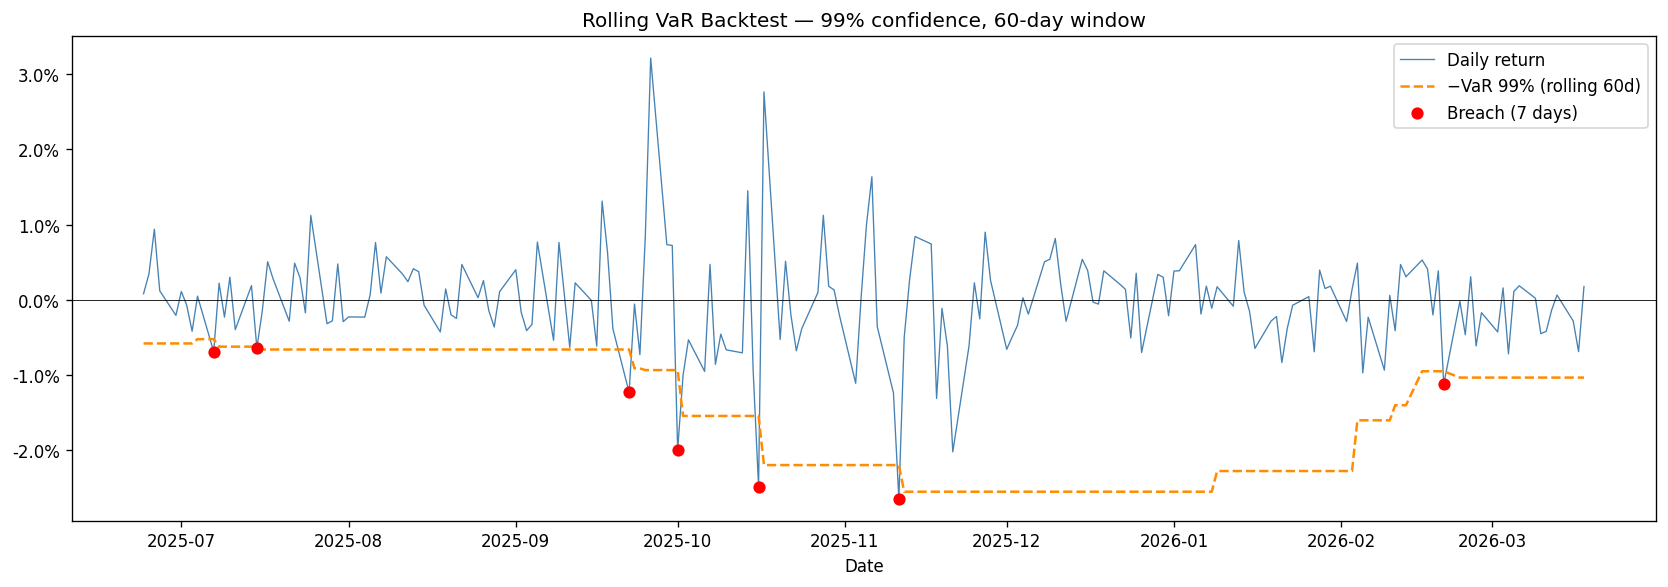

In [6]:
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(actual_returns.index, actual_returns, color="steelblue",
        linewidth=0.8, label="Daily return")
ax.plot(var_series.index, -var_series, color="darkorange",
        linewidth=1.5, linestyle="--", label=f"−VaR {CONFIDENCE:.0%} (rolling {WINDOW}d)")

if breach_dates:
    ax.scatter(
        breach_dates,
        actual_returns.loc[breach_dates],
        color="red", zorder=5, s=40,
        label=f"Breach ({len(breach_dates)} days)",
    )

ax.axhline(0, color="black", linewidth=0.5)
ax.set_title(f"Rolling VaR Backtest — {CONFIDENCE:.0%} confidence, {WINDOW}-day window")
ax.set_xlabel("Date")
ax.yaxis.set_major_formatter(FuncFormatter(lambda v, _: f"{v:.1%}"))
ax.legend()
plt.tight_layout()
plt.show()

In [20]:
if breach_dates:
    breach_df = pd.DataFrame({
        "date": breach_dates,
        "actual_return": actual_returns.loc[breach_dates].values,
        "var_estimate":  var_series.loc[breach_dates].values,
    })
    breach_df["excess_loss"] = breach_df["actual_return"].abs() - breach_df["var_estimate"]
    display(
        breach_df.style.format({
            "actual_return": "{:.4%}",
            "var_estimate":  "{:.4%}",
            "excess_loss":   "{:.4%}",
        })
    )
else:
    print("No breaches observed.")

,date,actual_return,var_estimate,excess_loss
0,2025-07-07 00:00:00,-0.6945%,0.5272%,0.1672%
1,2025-07-15 00:00:00,-0.6450%,0.6271%,0.0178%
2,2025-09-22 00:00:00,-1.2358%,0.6653%,0.5705%
3,2025-10-01 00:00:00,-2.0026%,0.9394%,1.0631%
4,2025-10-16 00:00:00,-2.4957%,1.5502%,0.9455%
5,2025-11-11 00:00:00,-2.6520%,2.2048%,0.4472%
6,2026-02-20 00:00:00,-1.1302%,0.9548%,0.1755%


### 3.3 P&L Attribution by Instrument
*Weighted contribution per instrument on breach days (bps of portfolio value). Analysis: `VaR_backtest_result.md` section 4*

In [ ]:
breach_attr = (
    returns[common]
    .loc[breach_dates]
    .multiply(weights[common])
    .mul(10_000)
)
breach_attr.index = breach_attr.index.date

display(
    breach_attr.style
    .format("{:+.1f} bps")
    .background_gradient(cmap="RdYlGn", axis=1, vmin=-50, vmax=50)
    .set_caption("Weighted P&L contribution per instrument on breach days (bps of portfolio value)")
    .set_table_styles([{
        "selector": "caption", 
        "props": [("font-weight", "bold"), ("font-size", "13px")]}])
)

instrument_id,ABBN,ALV_GR,ASML_NA,CHGOV_10Y,CHGOV_2Y,CHGOV_5Y,DBRGOV_5Y,FRGOV_7Y,NESN,NESN_CORP,NOVN,NOVN_CORP,ROG,SAN_FP,SIE_GR,SREN,UBSG,UBSG_CORP
2025-07-07,-4.1 bps,-1.0 bps,-4.2 bps,-2.6 bps,-2.2 bps,-2.8 bps,-3.1 bps,-0.5 bps,-3.4 bps,-1.2 bps,-7.9 bps,-1.9 bps,-7.7 bps,-2.6 bps,-8.1 bps,-4.6 bps,-10.1 bps,-1.6 bps
2025-07-15,-6.1 bps,-3.5 bps,-12.1 bps,+2.9 bps,+0.7 bps,+2.1 bps,+0.1 bps,+1.6 bps,-6.9 bps,-0.5 bps,-14.6 bps,-0.4 bps,-5.1 bps,-6.2 bps,-3.5 bps,-8.9 bps,-3.0 bps,-1.1 bps
2025-09-22,-14.4 bps,-7.0 bps,-17.3 bps,+18.7 bps,+6.6 bps,+7.5 bps,+5.7 bps,+3.8 bps,-23.9 bps,-1.3 bps,-16.3 bps,-0.5 bps,-30.0 bps,-14.6 bps,-9.9 bps,-13.7 bps,-18.0 bps,+0.9 bps
2025-10-01,-23.4 bps,-16.3 bps,-22.8 bps,+0.2 bps,-0.6 bps,+1.8 bps,-0.9 bps,-0.4 bps,-21.7 bps,-2.3 bps,-18.3 bps,-1.1 bps,-28.2 bps,-17.2 bps,-7.2 bps,-9.1 bps,-32.5 bps,-0.4 bps
2025-10-16,-23.8 bps,-15.7 bps,-32.3 bps,+3.4 bps,-0.1 bps,+1.5 bps,+0.7 bps,+0.8 bps,-31.6 bps,-5.4 bps,-31.8 bps,-4.5 bps,-29.2 bps,-21.3 bps,-17.2 bps,-14.2 bps,-24.1 bps,-4.8 bps
2025-11-11,-35.6 bps,-14.3 bps,-32.4 bps,+8.6 bps,+3.6 bps,+2.0 bps,+2.5 bps,+2.9 bps,-27.0 bps,+3.6 bps,-45.4 bps,-2.5 bps,-39.8 bps,-24.0 bps,-15.6 bps,-20.2 bps,-33.2 bps,+1.8 bps
2026-02-20,-17.6 bps,-8.1 bps,-13.9 bps,+4.3 bps,+1.3 bps,+1.4 bps,-2.0 bps,-0.8 bps,-15.4 bps,-2.1 bps,-13.5 bps,-1.6 bps,-5.6 bps,-5.9 bps,-10.0 bps,-5.3 bps,-16.2 bps,-1.9 bps


In [21]:
window_vol_ann = port_returns.rolling(WINDOW).std() * (252**0.5)

vol_context = breach_df[["actual_return", "var_estimate", "excess_loss"]].copy()
vol_context["est_window_vol"] = window_vol_ann.loc[breach_dates].values
vol_context["vol_utilization"] = vol_context["actual_return"].abs() / (
    vol_context["est_window_vol"] / (252**0.5)
)
vol_context.index = pd.DatetimeIndex(breach_dates).date

display(
    vol_context.style.format(
        {
            "actual_return": "{:.4%}",
            "var_estimate": "{:.4%}",
            "excess_loss": "{:.4%}",
            "est_window_vol": "{:.2%}",
            "vol_utilization": "{:.2f}x",
        }
    )
)

,actual_return,var_estimate,excess_loss,est_window_vol,vol_utilization
2025-07-07,-0.6945%,0.5272%,0.1672%,5.26%,2.09x
2025-07-15,-0.6450%,0.6271%,0.0178%,5.47%,1.87x
2025-09-22,-1.2358%,0.6653%,0.5705%,7.40%,2.65x
2025-10-01,-2.0026%,0.9394%,1.0631%,10.98%,2.89x
2025-10-16,-2.4957%,1.5502%,0.9455%,13.20%,3.00x
2025-11-11,-2.6520%,2.2048%,0.4472%,16.13%,2.61x
2026-02-20,-1.1302%,0.9548%,0.1755%,7.24%,2.48x


## 4. Kupiec POF Test
*Methodology: `VaR_backtesting_methodology.md` section 3 · Results: `VaR_backtest_result.md` section 2.1*

In [22]:
kupiec = result["kupiec"]
critical_lr = chi2.ppf(0.95, df=1)

print("Kupiec POF test — rolling backtest")
print(f"  Observations:      {result['n_observations']}")
print(f"  Expected breaches: {kupiec['expected_breaches']:.1f}")
print(f"  Observed breaches: {kupiec['observed_breaches']}")
print(f"  Observed rate:     {kupiec['observed_rate']:.2%}")
print(f"  LR statistic:      {kupiec['test_statistic']:.4f}  (χ²(1) critical = {critical_lr:.2f})")
print(f"  p-value:           {kupiec['p_value']:.4f}")
print(f"  Reject H₀:         {kupiec['reject_h0']}")
print()
verdict = (
    "FAIL — model is mis-calibrated"
    if kupiec["reject_h0"]
    else "PASS — breach rate is consistent with the claimed confidence level"
)
print(f"Verdict: {verdict}")

Kupiec POF test — rolling backtest
  Observations:      192
  Expected breaches: 1.9
  Observed breaches: 7
  Observed rate:     3.65%
  LR statistic:      8.0872  (χ²(1) critical = 3.84)
  p-value:           0.0045
  Reject H₀:         True

Verdict: FAIL — model is mis-calibrated


## 5. Christoffersen Independence & Conditional Coverage Test
*Methodology: `VaR_backtesting_methodology.md` section 4 · Results: `VaR_backtest_result.md` section 2.2–2.3*

Transition matrix
  n00 (no breach → no breach):  177   n01 (no breach → breach):   7
  n10 (breach → no breach):      7   n11 (breach → breach):     0

  P(breach | no breach yesterday): 3.80%
  P(breach | breach yesterday):    0.00%  ← should equal 1.00% if independent

Independence test  LR = 0.5327  χ²(1) critical = 3.84  p = 0.4655  reject = False
Conditional cov.   LR = 8.6199  χ²(2) critical = 5.99  p = 0.0134  reject = True


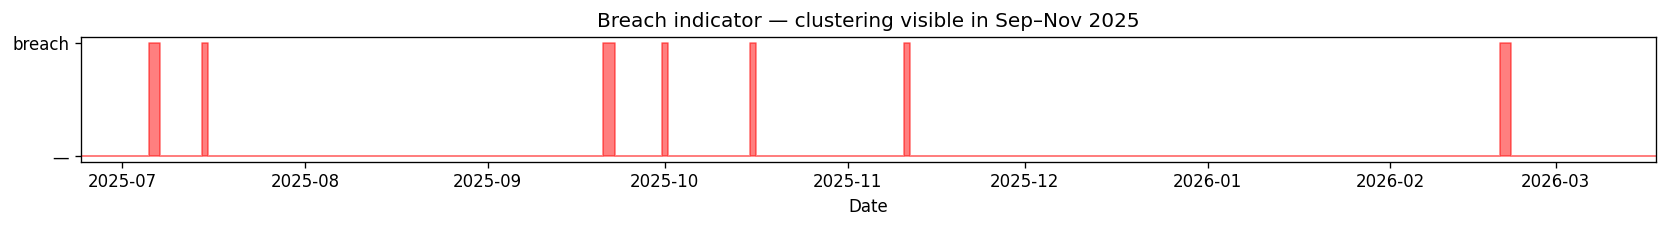

In [ ]:
breach_indicator = pd.Series(0, index=actual_returns.index)
breach_indicator.loc[breach_dates] = 1

ind = christoffersen_independence_test(breach_indicator)

lr_ind = ind["lr_independence"]
p_ind  = ind["p_independence"]
lr_cc  = kupiec["test_statistic"] + lr_ind
p_cc   = float(1 - chi2.cdf(lr_cc, df=2))

print("Transition matrix")
print(f"  n00 (no breach → no breach): {ind['n00']:4d}   n01 (no breach → breach): {ind['n01']:3d}")
print(f"  n10 (breach → no breach):   {ind['n10']:4d}   n11 (breach → breach):   {ind['n11']:3d}")
print()
print(f"  P(breach | no breach yesterday): {ind['pi_01']:.2%}")
print(f"  P(breach | breach yesterday):    {ind['pi_11']:.2%}  ← "
      f"should equal {1-CONFIDENCE:.2%} if independent")
print()
print(f"Independence test  LR = {lr_ind:.4f}  χ²(1) critical = {chi2.ppf(0.95, df=1):.2f}  "
      f"p = {p_ind:.4f}  reject = {ind['reject_independence']}")
print(f"Conditional cov.   LR = {lr_cc:.4f}  χ²(2) critical = {chi2.ppf(0.95, df=2):.2f}  "
      f"p = {p_cc:.4f}  reject = {p_cc < 0.05}")

fig, ax = plt.subplots(figsize=(14, 2))
ax.fill_between(
    breach_indicator.index, breach_indicator, color="red", alpha=0.5, step="mid"
)
ax.set_yticks([0, 1])
ax.set_yticklabels(["—", "breach"])
ax.set_xlim(breach_indicator.index.min(), breach_indicator.index.max())
ax.set_title("Breach indicator — clustering visible in Sep–Nov 2025")
ax.set_xlabel("Date")
plt.tight_layout()
plt.show()

## 6. Window-Size Sensitivity
*Methodology: `VaR_backtesting_methodology.md` section 6.3 · Results: `VaR_backtest_result.md` section 3*

,n_obs,expected,observed,breach_rate,LR,p_value,reject_H0
window,,,,,,,
20,232,2.3,18,7.76%,43.493,0.0000,True
40,212,2.1,11,5.19%,18.844,0.0000,True
60,192,1.9,7,3.65%,8.087,0.0045,True
90,162,1.6,4,2.47%,2.506,0.1134,False
120,132,1.3,5,3.79%,6.063,0.0138,True


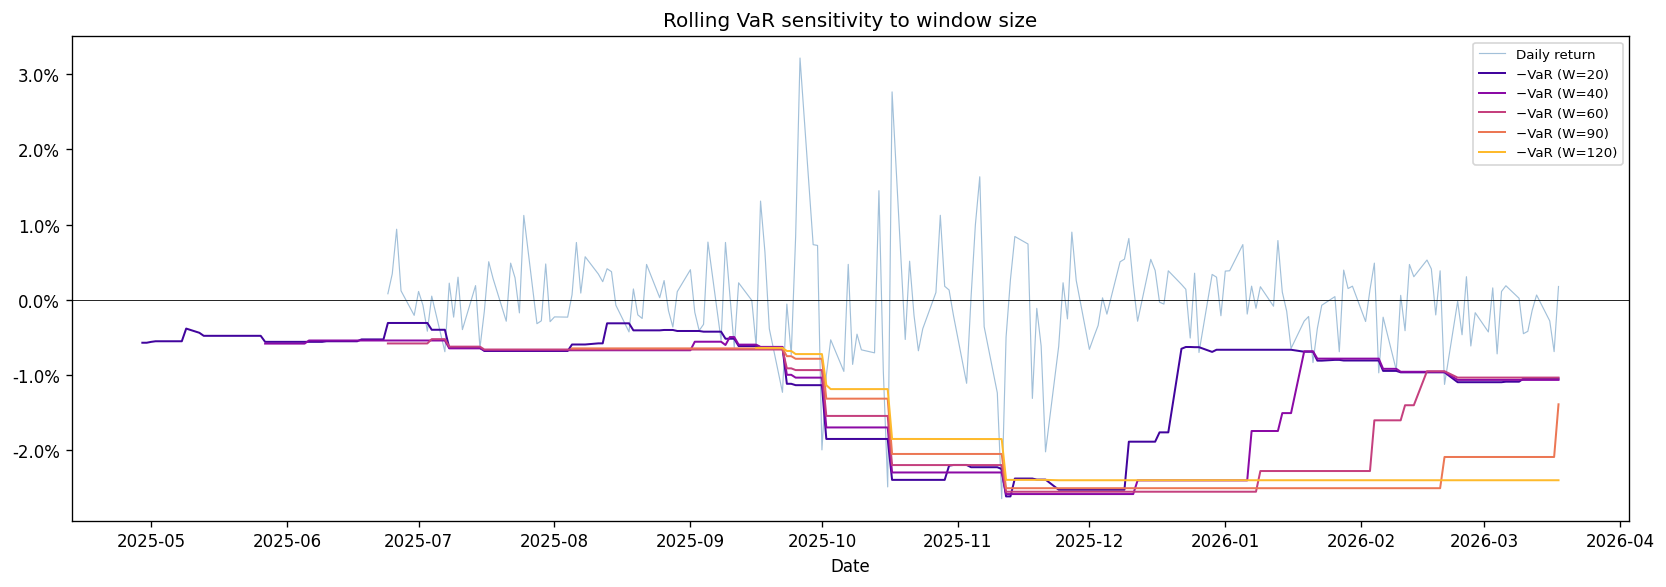

In [ ]:
windows = [20, 40, 60, 90, 120]
rows = []

for w in windows:
    res = run_rolling_backtest(port_returns, window=w, confidence=CONFIDENCE)
    k = res["kupiec"]
    rows.append({
        "window": w,
        "n_obs": res["n_observations"],
        "expected": res["expected_breaches"],
        "observed": res["n_breaches"],
        "breach_rate": res["n_breaches"] / res["n_observations"],
        "LR": k["test_statistic"],
        "p_value": k["p_value"],
        "reject_H0": k["reject_h0"],
    })

sensitivity_df = pd.DataFrame(rows).set_index("window")
display(
    sensitivity_df.style
    .format({
        "expected":    "{:.1f}",
        "breach_rate": "{:.2%}",
        "LR":          "{:.3f}",
        "p_value":     "{:.4f}",
    })
    .map(lambda v: "color: red" if v is True else "", subset=["reject_H0"])
)

# Plot VaR time series for each window
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(actual_returns.index, actual_returns, color="steelblue",
        linewidth=0.7, alpha=0.5, label="Daily return")

colors = plt.colormaps["plasma"](np.linspace(0.1, 0.85, len(windows)))
for w, color in zip(windows, colors, strict=True):
    res = run_rolling_backtest(port_returns, window=w, confidence=CONFIDENCE)
    ax.plot(res["var_series"].index, -res["var_series"],
            linewidth=1.2, color=color, label=f"VaR (W={w})")

ax.axhline(0, color="black", linewidth=0.5)
ax.set_title("Rolling VaR sensitivity to window size")
ax.set_xlabel("Date")
ax.yaxis.set_major_formatter(FuncFormatter(lambda v, _: f"{v:.1%}"))
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

## 7. EWMA Volatility-Weighted VaR
*Methodology: `VaR_backtesting_methodology.md` section 6.2 · Results: `VaR_backtest_result.md` section 2.1*

Metric                              Flat HS      EWMA HS
--------------------------------------------------------
Observations                            192          192
Expected breaches                       1.9          1.9
Observed breaches                         7            6
Observed rate                        3.65%       3.12%
Kupiec LR                            8.0872       5.6014
Kupiec p-value                       0.0045       0.0179
Reject H₀ (5%)                            1            1


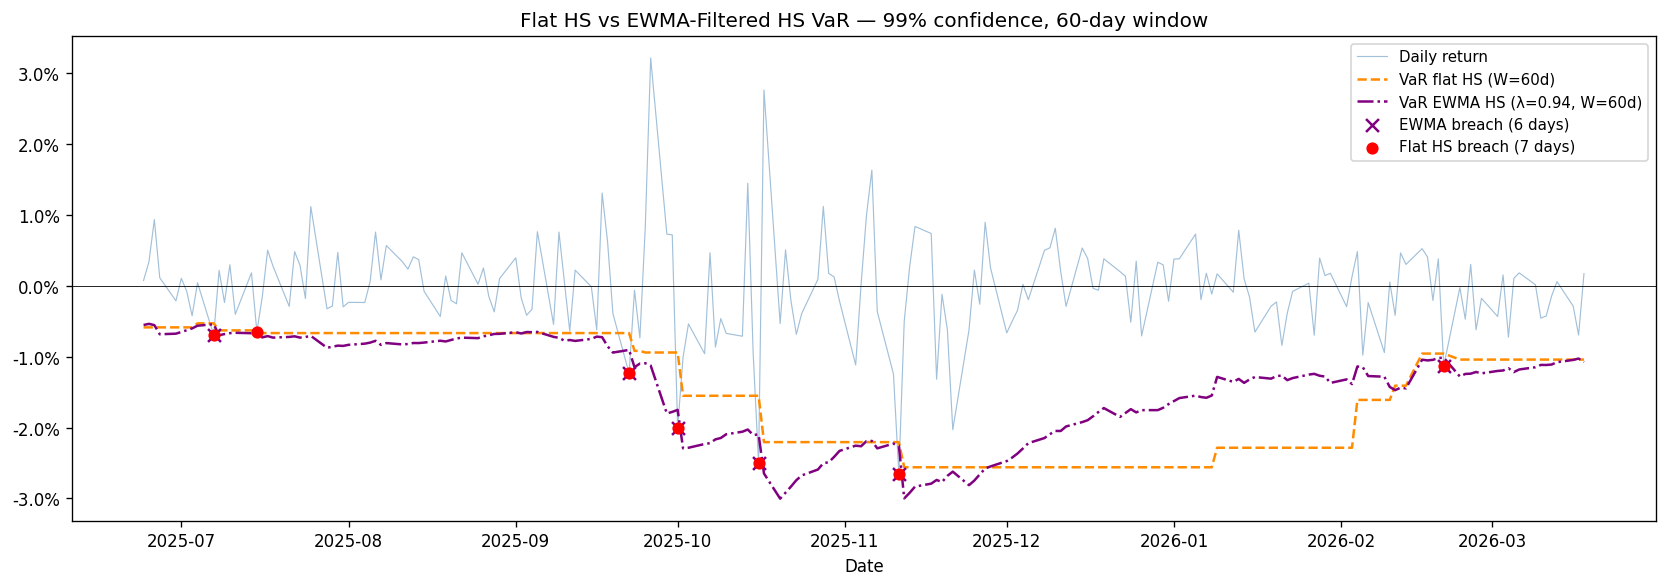

In [30]:
EWMA_LAMBDA = 0.94
result_ewma = run_rolling_backtest_ewma(
    port_returns, window=WINDOW, confidence=CONFIDENCE, lam=EWMA_LAMBDA
)

# Side-by-side summary
print(f"{'Metric':<30} {'Flat HS':>12} {'EWMA HS':>12}")
print("-" * 56)
print(f"{'Observations':<30} {result['n_observations']:>12} {result_ewma['n_observations']:>12}")
print(f"{'Expected breaches':<30} {result['expected_breaches']:>12.1f} "
      f"{result_ewma['expected_breaches']:>12.1f}")
print(f"{'Observed breaches':<30} {result['n_breaches']:>12} {result_ewma['n_breaches']:>12}")
print(f"{'Observed rate':<30} {result['n_breaches']/result['n_observations']:>11.2%} "
      f"{result_ewma['n_breaches']/result_ewma['n_observations']:>11.2%}")
print(f"{'Kupiec LR':<30} {result['kupiec']['test_statistic']:>12.4f} "
      f"{result_ewma['kupiec']['test_statistic']:>12.4f}")
print(f"{'Kupiec p-value':<30} {result['kupiec']['p_value']:>12.4f} "
      f"{result_ewma['kupiec']['p_value']:>12.4f}")
print(f"{'Reject H₀ (5%)':<30} {result['kupiec']['reject_h0']:>12} "
      f"{result_ewma['kupiec']['reject_h0']:>12}")

# Overlay chart
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(actual_returns.index, actual_returns, color="steelblue",
        linewidth=0.7, alpha=0.5, label="Daily return")
ax.plot(var_series.index, -var_series, color="darkorange",
        linewidth=1.5, linestyle="--", label=f"VaR flat HS (W={WINDOW}d)")
ax.plot(result_ewma["var_series"].index, -result_ewma["var_series"],
        color="purple", linewidth=1.5, linestyle="-.",
        label=f"VaR EWMA HS (λ={EWMA_LAMBDA}, W={WINDOW}d)")

if result_ewma["breach_dates"]:
    ax.scatter(
        result_ewma["breach_dates"],
        actual_returns.loc[result_ewma["breach_dates"]],
        color="purple", marker="x", zorder=5, s=60,
        label=f"EWMA breach ({result_ewma['n_breaches']} days)",
    )
if breach_dates:
    ax.scatter(
        breach_dates,
        actual_returns.loc[breach_dates],
        color="red", zorder=5, s=40,
        label=f"Flat HS breach ({len(breach_dates)} days)",
    )

ax.axhline(0, color="black", linewidth=0.5)
ax.set_title(f"Flat HS vs EWMA-Filtered HS VaR — {CONFIDENCE:.0%} confidence, {WINDOW}-day window")
ax.set_xlabel("Date")
ax.yaxis.set_major_formatter(FuncFormatter(lambda v, _: f"{v:.1%}"))
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

## 8. ES / CVaR Backtest
*Methodology: `VaR_backtesting_methodology.md` section 5 · Results: `VaR_backtest_result.md` section 2.5*

ES Coverage Test — 99% rolling historical simulation
  Breach days used:         7
  Mean realised loss:       1.5508%
  Mean ES estimate:         1.2399%
  Coverage ratio:           1.2507x
  Bootstrap 95% CI:         [1.0981x, 1.4706x]
  Reject H₀ (CI > 1.0):     True

Verdict: FAIL — ES systematically underestimates tail severity


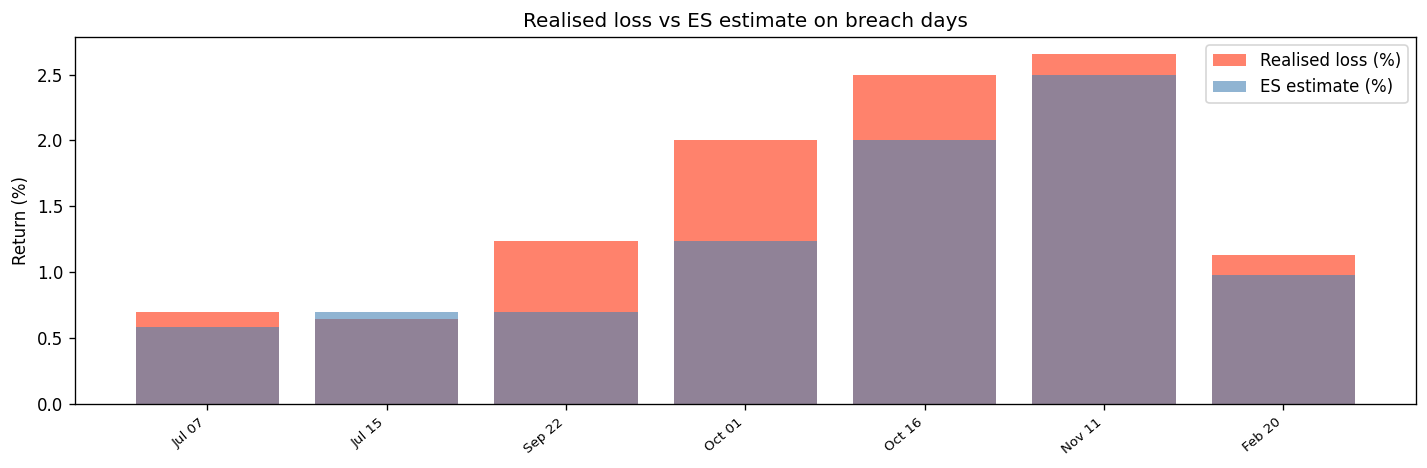

In [ ]:
cvar_series = result["cvar_series"]

es_test = es_coverage_test(
    actual_returns, var_series, cvar_series, n_bootstrap=5000, seed=42
)

ci_lo, ci_hi = es_test["bootstrap_ci_95"]
print("ES Coverage Test — 99% rolling historical simulation")
print(f"  {'Breach days used:':<25} {es_test['n_breach_days']}")
print(f"  {'Mean realized loss:':<25} {es_test['mean_realized_loss']:.4%}")
print(f"  {'Mean ES estimate:':<25} {es_test['mean_es_estimate']:.4%}")
print(f"  {'Coverage ratio:':<25} {es_test['es_coverage_ratio']:.4f}x")
print(f"  {'Bootstrap 95% CI:':<25} [{ci_lo:.4f}x, {ci_hi:.4f}x]")
print(f"  {'Reject H₀ (CI > 1.0):':<25} {es_test['reject_h0']}")
print()
verdict_es = (
    "FAIL — ES systematically underestimates tail severity"
    if es_test["reject_h0"]
    else "PASS — tail severity consistent with ES model"
)
print(f"Verdict: {verdict_es}")

bd = pd.DatetimeIndex(breach_dates)
fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(
    range(len(bd)),
    -actual_returns.loc[bd].values * 100,
    label="Realized loss (%)",
    color="tomato", alpha=0.8,
)
ax.bar(
    range(len(bd)),
    cvar_series.loc[bd].values * 100,
    label="ES estimate (%)",
    color="steelblue", alpha=0.6,
)
ax.set_xticks(range(len(bd)))
ax.set_xticklabels([d.strftime("%b %d") for d in bd], rotation=40, ha="right", fontsize=8)
ax.set_ylabel("Return (%)")
ax.set_title("Realized loss vs ES estimate on breach days")
ax.legend()
plt.tight_layout()
plt.show()

## 9. Basel Traffic Light
*Methodology: `VaR_backtesting_methodology.md` section 8 · Results: `VaR_backtest_result.md` section 2.6*

In [27]:
BASE_MULTIPLIER = 3.0

flat_tl = basel_traffic_light(result["n_observations"],      result["n_breaches"],      CONFIDENCE)
ewma_tl = basel_traffic_light(result_ewma["n_observations"], result_ewma["n_breaches"], CONFIDENCE)

for label, tl in [("Flat HS", flat_tl), ("EWMA HS", ewma_tl)]:
    eff_mult = BASE_MULTIPLIER + tl["capital_multiplier_addon"]
    ref = tl["basel_reference"]
    print(label)
    print(f"  {'Zone:':<25} {tl['zone'].upper()}")
    print(f"  {'Breaches:':<25} {tl['n_breaches']}  "
          f"(green ≤{tl['green_max']}, yellow ≤{tl['yellow_max']}, red >{tl['yellow_max']})")
    print(f"  {'Capital multiplier:':<25} "
          f"{BASE_MULTIPLIER:.1f} + {tl['capital_multiplier_addon']:.2f} = {eff_mult:.2f}")
    print(f"  {'Basel reference (250d):':<25} green ≤{ref['green_max']}, "
          f"yellow ≤{ref['yellow_max']}, red >{ref['yellow_max']}")
    print()

Flat HS
  Zone:                     YELLOW
  Breaches:                 7  (green ≤4, yellow ≤9, red >9)
  Capital multiplier:       3.0 + 0.62 = 3.62
  Basel reference (250d):   green ≤4, yellow ≤9, red >9

EWMA HS
  Zone:                     YELLOW
  Breaches:                 6  (green ≤4, yellow ≤9, red >9)
  Capital multiplier:       3.0 + 0.51 = 3.51
  Basel reference (250d):   green ≤4, yellow ≤9, red >9

